# Model Tracker and Submission Manager
### Purpose: Track all models in checkpoint directories and manage submissions


In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()
_start = Path(os.getenv("PROJECT_ROOT") or Path.cwd()).resolve()
root = next(p for p in [_start, *_start.parents] if (p / "config.yaml").exists())
sys.path[:0] = [str(root), str(root / "src")]

import numpy as np
import torch
from src.utils.config import Config
from src.utils.helpers import init_notebook, p, t, c
from src.data.checkpoint import generate_best_model_report, main_model_tracking_pipeline, show_model_details
import random

# Initialize configuration
config = Config.load(root = root)

init_notebook(config.train.seed)



auto_adjust disabled
=== init_notebook ===
Done


In [2]:
torch.manual_seed(config.train.seed)
np.random.seed(config.train.seed)
random.seed(config.train.seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(config.train.seed)
    torch.cuda.manual_seed_all(config.train.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
p("Device", device)
p("Config loaded", config.paths.root)


Device: cpu
Config loaded: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection


### Execute Pipeline


=== Executing Model Tracking and Submission Management Pipeline ===

=== Model Tracking and Submission Management Pipeline ===

=== Step 1: Scanning All Models ===
Base path for model search: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints
Found checkpoint base directories: ['03', '16', '10', '07']
Scanning checkpoint directory: 03
Found 4 .pth files in 03
Scanning checkpoint directory: 16
Found 2 .pth files in 16
Scanning checkpoint directory: 10
Found 10 .pth files in 10
Scanning checkpoint directory: 07
Found 6 .pth files in 07
Total models found: 22

=== Step 2: Generating Missing Submissions ===
=== Generating Missing Submissions ===
Models without submissions: 8

Progress: 1/4
Creating submission for: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/03/simple_cnn/rgb/size_128/v001/best_model.pth
Trying to create submission for: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/03/simple_cnn/rgb/size_128

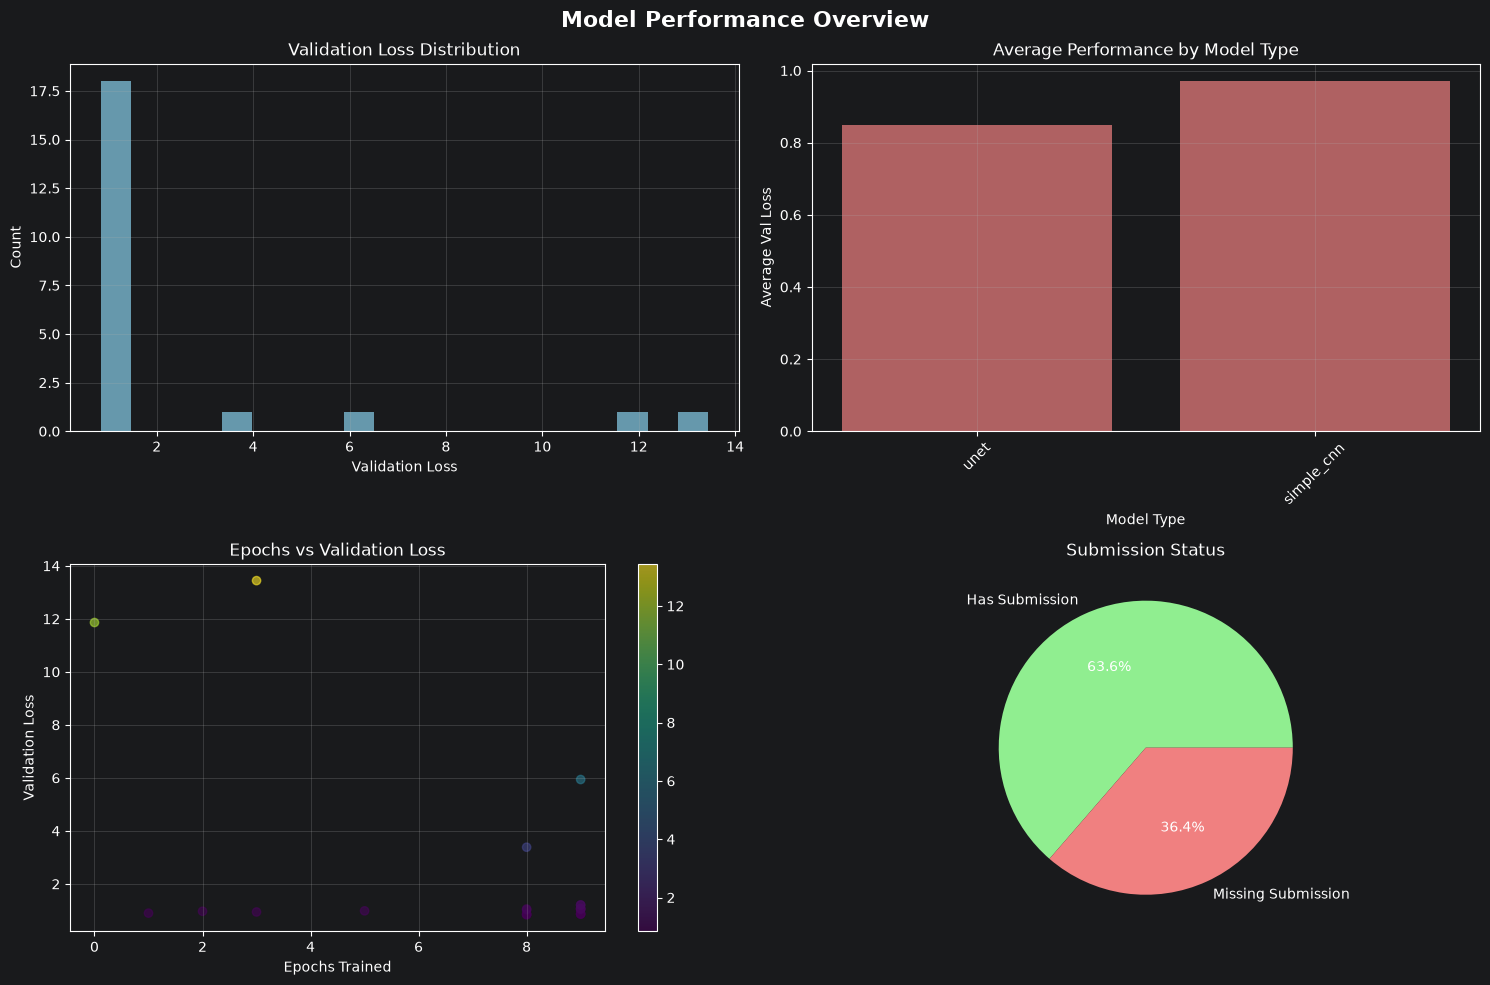


=== Step 7: Generating Submission Links Report ===

Submission links report saved: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/model_submission_links_report.md

=== Step 8: Saving Detailed Model Information ===
Detailed model CSV saved: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/all_models_detailed.csv

=== Pipeline Summary ===

Total models found: 22
Models with submissions: 22
Models with validation loss: 22
Submissions generated: 4
Best model: unet (rgb) - Val Loss: 0.8343024730682373
Pipeline completed successfully!


In [3]:
# Run the main pipeline
t("Executing Model Tracking and Submission Management Pipeline")

try:
    results = main_model_tracking_pipeline(config)
    p("Pipeline completed successfully!", color1 = c.GREEN)
except Exception as e:
    p(f"Pipeline failed with error: {str(e)}", color1 = c.RED)
    import traceback

    traceback.print_exc()


### Show details for the best model


In [4]:
if 'results' in locals() and results:
    ranked_models = results.get("ranked_models", [])
    if ranked_models:
        t("Best Model Details")
        show_model_details(ranked_models[0])


=== Best Model Details ===
=== Model Details: best_model.pth ===
Model Name: unet
Mode: rgb
Image Size: 64
Version: v001
Filters
Checkpoint Directory: 10
File Size: 355.42 MB
Created Date: 2026-09-24 00:33:00
Epochs Trained: 8
Validation Loss: 0.834302
Training Loss: 0.889345
=== Performance Metrics ===
Iou: 0.2569
Accuracy: 0.6154
Precision: 0.3629
Recall: 0.6466
F1 Score: 0.4460
Has Submission: Yes
Submission Path: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/10/unet/rgb/size_64/v001/SUBMISSION.json


### Generate Final Best Model Report


In [5]:
if 'results' in locals() and results:
    ranked_models = results.get("ranked_models", [])
    if ranked_models:
        best_report_path = generate_best_model_report(ranked_models, config)


=== Best Model Report Generation ===
Best model report saved: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/BEST_MODEL_REPORT.md
Best model info saved: /Volumes/Colibri/CascadeProjects/cap6415-tree-canopy-detection/checkpoints/BEST_MODEL.txt
